# Lib

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

import cv2
import os


In [2]:
import os, shutil
import random
import numpy as np
import pandas as pd
import cv2
import skimage
import matplotlib.pyplot as plt
import skimage.segmentation
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')


# Tiền xử lý dữ liệu

## Load data

In [3]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle

labels = ['Pneumonia', 'Normal', 'Covid19']
img_size = 224

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
    return data

# Load data (only PNEUMONIA and NORMAL, COVID19 is excluded)
train = get_data("/kaggle/input/train-covid19-pneumonia-normal/Train_COVID19_Pneumonia_Normal/train")
val = get_data("/kaggle/input/train-covid19-pneumonia-normal/Train_COVID19_Pneumonia_Normal/val")

# Trộn ảnh để tránh hiện tượng mô hình học theo thứ tự ảnh
train = shuffle(train, random_state=42)
val = shuffle(val, random_state=42)

# Đưa ảnh vào dạng NumPy - Reshape thành (N, 224, 224, 1) → ảnh grayscale 1 kênh
x_train = np.array([i[0] for i in train]).reshape(-1, img_size, img_size, 1)
y_train = np.array([i[1] for i in train])

x_val = np.array([i[0] for i in val]).reshape(-1, img_size, img_size, 1)
y_val = np.array([i[1] for i in val])

# Normalize the pixel values to be between 0 and 1
x_train = x_train / 255.0
x_val = x_val / 255.0

# Print shapes to verify everything is correct
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_val.shape)
print("Test labels shape:", y_val.shape)

# Check class distribution
print("\nClass distribution in training set:")
print(f"PNEUMONIA: {np.sum(y_train == 0)}")
print(f"NORMAL: {np.sum(y_train == 1)}")
print(f"Covid19: {np.sum(y_train == 2)}")

print("\nClass distribution in val set:")
print(f"PNEUMONIA: {np.sum(y_val == 0)}")
print(f"NORMAL: {np.sum(y_val == 1)}")
print(f"Covid19: {np.sum(y_val == 2)}")

Training data shape: (21418, 224, 224, 1)
Training labels shape: (21418,)
Test data shape: (1337, 224, 224, 1)
Test labels shape: (1337,)

Class distribution in training set:
PNEUMONIA: 7912
NORMAL: 10153
Covid19: 3353

Class distribution in val set:
PNEUMONIA: 494
NORMAL: 634
Covid19: 209


## Hiện thị mẫu

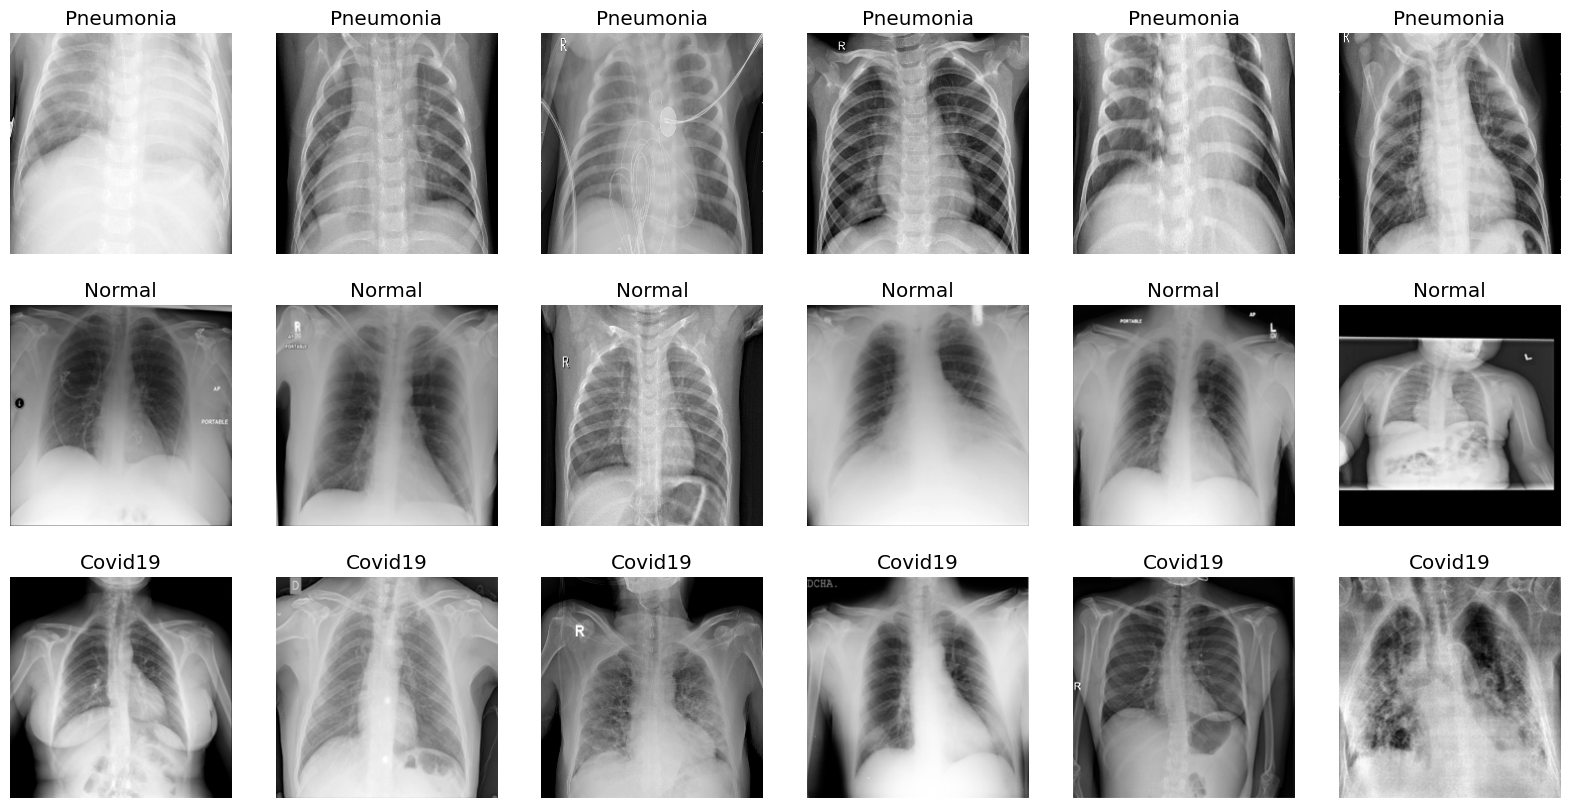

In [4]:
def show_samples_per_class(images, labels, class_names, samples_per_class=6):
    plt.figure(figsize=(20, 10))
    index = 1
    
    for class_id, class_name in enumerate(class_names):
        count = 0
        for i in range(len(labels)):
            if labels[i] == class_id:
                plt.subplot(len(class_names), samples_per_class, index)
                plt.imshow(images[i].reshape(img_size, img_size), cmap='gray')
                plt.title(class_name)
                plt.axis("off")
                index += 1
                count += 1
                if count == samples_per_class:
                    break
                    
    plt.show()

show_samples_per_class(x_train, y_train, labels)


## Tăng cường ảnh

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        rotation_range = 30,
        zoom_range = 0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip = True,
        vertical_flip=False
)
datagen.fit(x_train)

# xây dựng mô hình

In [104]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(224,224,1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPool2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = Dropout(0.1)(x)
x = BatchNormalization()(x)
x = MaxPool2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPool2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPool2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same' , name="last_conv")(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = MaxPool2D((2,2), padding='same')(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = MaxPool2D((2,2), padding='same')(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_59"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 4, 4, 256)      │             

 Total params: 1,005,443 (3.84 MB)

 Trainable params: 1,004,227 (3.83 MB)

 Non-trainable params: 1,216 (4.75 KB)

# Huấn luyện model
Tối ưu bằng Adam optimizer, learning rate = 1e-4.

Loss function: Categorical Cross-Entropy.


Batch size: 32 – 64.

Sử dụng Early Stopping để tránh overfitting.

Model Checkpoint để lưu mô hình có hiệu suất tốt nhất.


In [7]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.00000001)


In [10]:


checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


In [11]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=15,
    validation_data=(x_val, y_val),
    callbacks=[learning_rate_reduction, checkpoint]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1763869114.205969     110 service.cc:148] XLA service 0x7a91f0098e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763869114.206791     110 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763869114.774269     110 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/335 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.4336 - loss: 2.1223   

I0000 00:00:1763869123.989508     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

335/335 ━━━━━━━━━━━━━━━━━━━━ 70s 208ms/step - accuracy: 0.8089 - loss: 0.4376 - val_accuracy: 0.5318 - val_loss: 1.1008 - learning_rate: 0.0010
Epoch 3/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8700 - loss: 0.3306
Epoch 3: val_accuracy improved from 0.53179 to 0.75841, saving model to best_model.h5


335/335 ━━━━━━━━━━━━━━━━━━━━ 70s 209ms/step - accuracy: 0.8700 - loss: 0.3306 - val_accuracy: 0.7584 - val_loss: 0.8590 - learning_rate: 0.0010
Epoch 4/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.8888 - loss: 0.2821
Epoch 4: val_accuracy improved from 0.75841 to 0.86238, saving model to best_model.h5


335/335 ━━━━━━━━━━━━━━━━━━━━ 71s 210ms/step - accuracy: 0.8888 - loss: 0.2821 - val_accuracy: 0.8624 - val_loss: 0.3887 - learning_rate: 0.0010
Epoch 5/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9095 - loss: 0.2553
Epoch 5: val_accuracy did not improve from 0.86238
335/335 ━━━━━━━━━━━━━━━━━━━━ 69s 207ms/step - accuracy: 0.9095 - loss: 0.2553 - val_accuracy: 0.7951 - val_loss: 0.4671 - learning_rate: 0.0010
Epoch 6/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9109 - loss: 0.2421
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 6: val_accuracy did not improve from 0.86238
335/335 ━━━━━━━━━━━━━━━━━━━━ 70s 208ms/step - accuracy: 0.9109 - loss: 0.2421 - val_accuracy: 0.7906 - val_loss: 0.5316 - learning_rate: 0.0010
Epoch 7/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9366 - loss: 0.1793
Epoch 7: val_accuracy did not improve from 0.86238
335/335 ━━━━━━━━━━━━━━━━━━━━ 70s 210ms/step - accuracy: 0.9367 - loss: 0.1

335/335 ━━━━━━━━━━━━━━━━━━━━ 69s 207ms/step - accuracy: 0.9504 - loss: 0.1405 - val_accuracy: 0.8699 - val_loss: 0.2940 - learning_rate: 9.0000e-05
Epoch 10/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9566 - loss: 0.1262
Epoch 10: val_accuracy improved from 0.86986 to 0.92221, saving model to best_model.h5


335/335 ━━━━━━━━━━━━━━━━━━━━ 70s 208ms/step - accuracy: 0.9566 - loss: 0.1262 - val_accuracy: 0.9222 - val_loss: 0.1885 - learning_rate: 9.0000e-05
Epoch 11/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9536 - loss: 0.1371
Epoch 11: val_accuracy did not improve from 0.92221
335/335 ━━━━━━━━━━━━━━━━━━━━ 69s 206ms/step - accuracy: 0.9536 - loss: 0.1371 - val_accuracy: 0.8893 - val_loss: 0.2492 - learning_rate: 9.0000e-05
Epoch 12/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9567 - loss: 0.1281
Epoch 12: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.

Epoch 12: val_accuracy did not improve from 0.92221
335/335 ━━━━━━━━━━━━━━━━━━━━ 69s 206ms/step - accuracy: 0.9568 - loss: 0.1281 - val_accuracy: 0.8646 - val_loss: 0.3103 - learning_rate: 9.0000e-05
Epoch 13/15
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9561 - loss: 0.1314
Epoch 13: val_accuracy did not improve from 0.92221
335/335 ━━━━━━━━━━━━━━━━━━━━ 70s 207ms/step - accuracy:

In [12]:
print("Loss of the model is - " , model.evaluate(x_val,y_val)[0])
print("Accuracy of the model is - " , model.evaluate(x_val,y_val)[1]*100 , "%")


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8998 - loss: 0.2254
Loss of the model is -  0.2178497463464737
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8998 - loss: 0.2254
Accuracy of the model is -  90.05235433578491 %


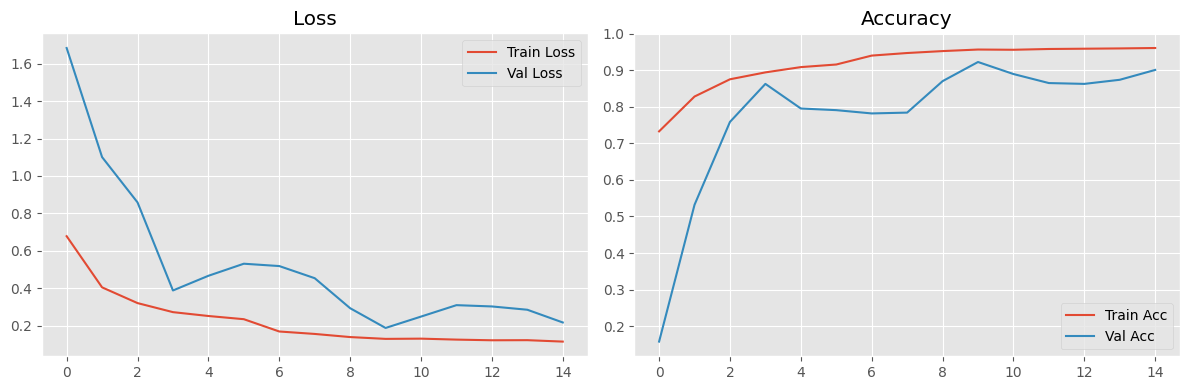

In [13]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# Đánh giá mô hình

In [32]:
from sklearn.metrics import accuracy_score

y_prob = model.predict(x_val)

y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_val, y_pred)

print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy: 0.9005 (90.05%)


## Accuracy, Precision, Recall, F1-score.

In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

label_names = ['Pneumonia', 'Normal', 'Covid19']



precision, recall, f1, support = precision_recall_fscore_support(
    y_val, y_pred, average=None, zero_division=0
)

acc_per_class = recall

print("\n" + "="*75)
print("CHI TIẾT METRICS CHO TỪNG CLASS")
print("="*75)
print(f"{'Class':<12} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Accuracy':<10} {'Support':<8}")
print("-" * 75)

for i in range(3):
    print(f"{label_names[i]:<12} {precision[i]:<10.4f} {recall[i]:<10.4f} "
          f"{f1[i]:<10.4f} {acc_per_class[i]:<10.4f} {support[i]:<8}")

# Macro averages
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)
macro_acc = np.mean(acc_per_class)

print("-" * 75)
print(f"{'Macro Avg':<12} {macro_precision:<10.4f} {macro_recall:<10.4f} "
      f"{macro_f1:<10.4f} {macro_acc:<10.4f}")



CHI TIẾT METRICS CHO TỪNG CLASS
Class        Precision  Recall     F1-Score   Accuracy   Support 
---------------------------------------------------------------------------
Pneumonia    0.9440     0.9899     0.9664     0.9899     494     
Normal       0.9845     0.8028     0.8844     0.8028     634     
Covid19      0.6821     0.9856     0.8063     0.9856     209     
---------------------------------------------------------------------------
Macro Avg    0.8702     0.9261     0.8857     0.9261    


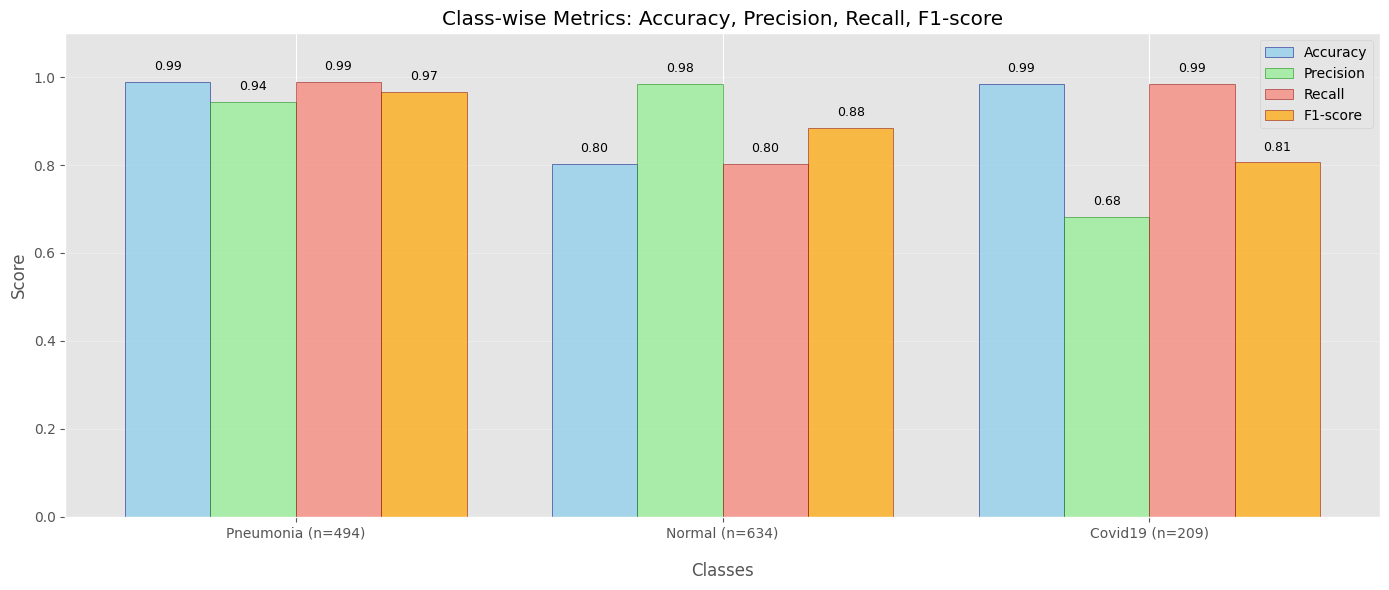

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_classwise_metrics(y_true, y_pred, class_names):
    """
    Vẽ biểu đồ class-wise metrics: Accuracy, Precision, Recall, F1-score
    """
    n_classes = len(class_names)
    
    # Tính metrics cho từng lớp
    accuracies = []
    precisions = precision_score(y_true, y_pred, average=None, zero_division=0)
    recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    class_counts = []
    for i in range(n_classes):
        class_mask = (y_true == i)
        class_pred = y_pred[class_mask]
        class_true = y_true[class_mask]
        acc = accuracy_score(class_true, class_pred) if len(class_true) > 0 else 0
        accuracies.append(acc)
        class_counts.append(len(class_true))
    
    # Vẽ biểu đồ
    x = np.arange(n_classes)
    width = 0.2  # độ rộng mỗi cột

    plt.figure(figsize=(14,6))
    plt.bar(x - 1.5*width, accuracies, width, label='Accuracy', color='skyblue', edgecolor='navy', alpha=0.7)
    plt.bar(x - 0.5*width, precisions, width, label='Precision', color='lightgreen', edgecolor='green', alpha=0.7)
    plt.bar(x + 0.5*width, recalls, width, label='Recall', color='salmon', edgecolor='darkred', alpha=0.7)
    plt.bar(x + 1.5*width, f1_scores, width, label='F1-score', color='orange', edgecolor='darkred', alpha=0.7)
    
    # Thêm nhãn giá trị lên từng cột
    for i in range(n_classes):
        plt.text(x[i] - 1.5*width, accuracies[i]+0.02, f'{accuracies[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] - 0.5*width, precisions[i]+0.02, f'{precisions[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + 0.5*width, recalls[i]+0.02, f'{recalls[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + 1.5*width, f1_scores[i]+0.02, f'{f1_scores[i]:.2f}', ha='center', va='bottom', fontsize=9)

    xtick_labels = [f"{name} (n={count})\n" for name, count in zip(class_names, class_counts)]
    plt.xticks(x, xtick_labels, rotation=0, ha='center')
    plt.ylim(0, 1.1)
    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Class-wise Metrics: Accuracy, Precision, Recall, F1-score')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return accuracies, precisions, recalls, f1_scores, class_counts

# Sử dụng:
accuracies, precisions, recalls, f1_scores, counts = plot_classwise_metrics(y_val, y_pred, label_names)


## Confusion Matrix

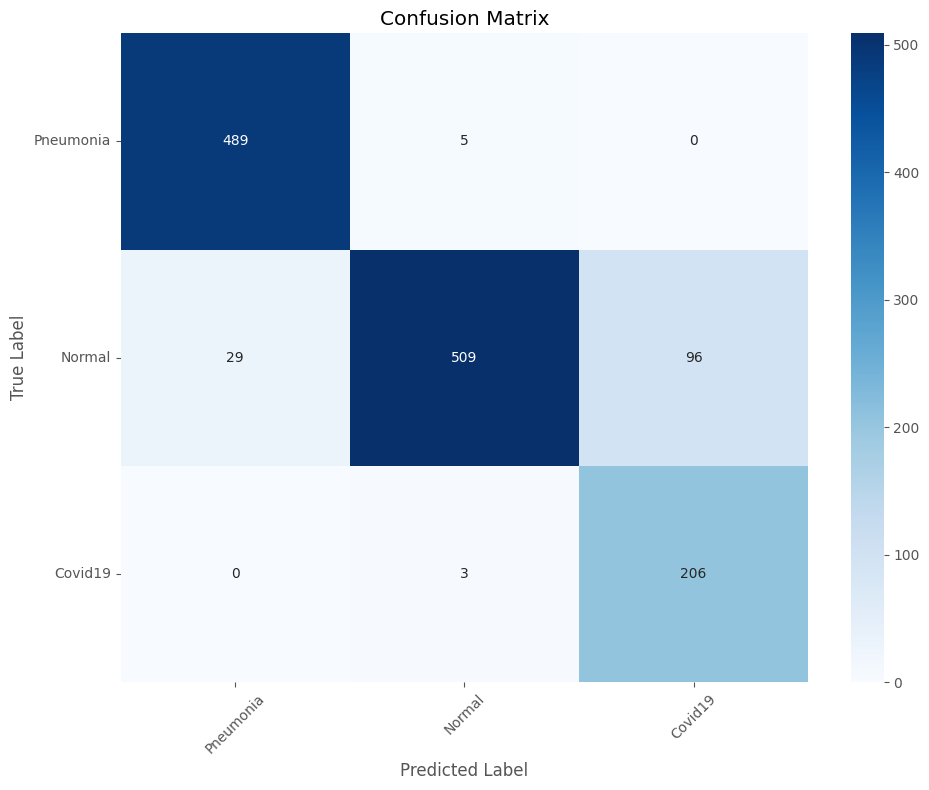

In [38]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Vẽ confusion matrix với heatmap"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(y_val, y_pred, label_names)

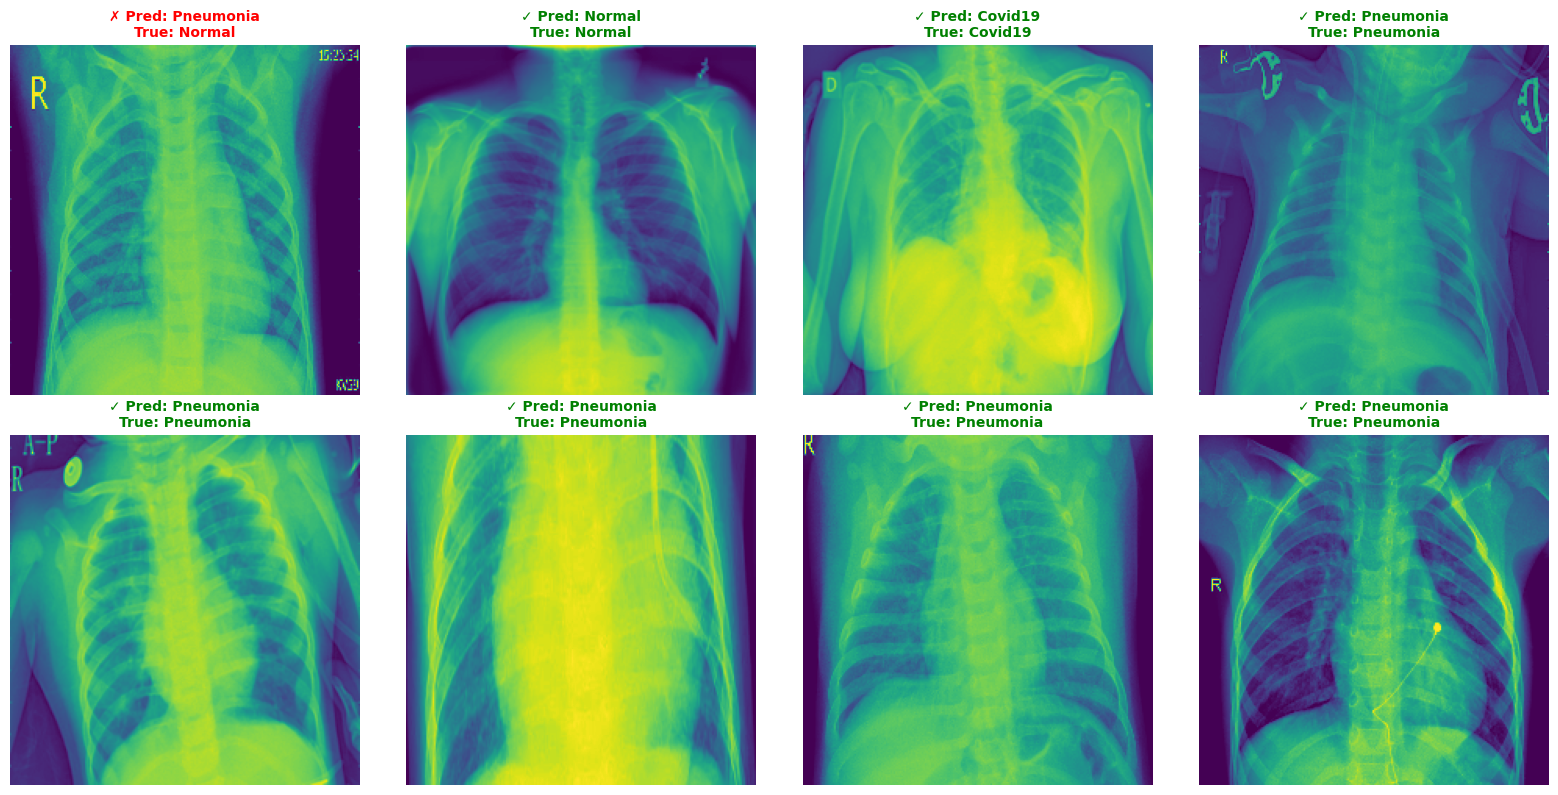

In [108]:
def display_predictions(images, true_labels, pred_labels, class_names, n_samples=8):
    """Hiển thị ảnh với nhãn dự đoán và đánh dấu đúng/sai"""

    plt.figure(figsize=(16, 8))

    for i in range(n_samples):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])
        plt.axis('off')

        true_label = class_names[true_labels[i]]
        pred_label = class_names[pred_labels[i]]

        # Đánh dấu đúng (✓) hoặc sai (✗)
        if true_labels[i] == pred_labels[i]:
            color = 'green'
            mark = '✓'
        else:
            color = 'red'
            mark = '✗'

        plt.title(f"{mark} Pred: {pred_label}\nTrue: {true_label}",
                 color=color, fontsize=10, weight='bold')

    plt.tight_layout()
    plt.show()

display_predictions(x_val, y_val, y_pred, label_names, 8)


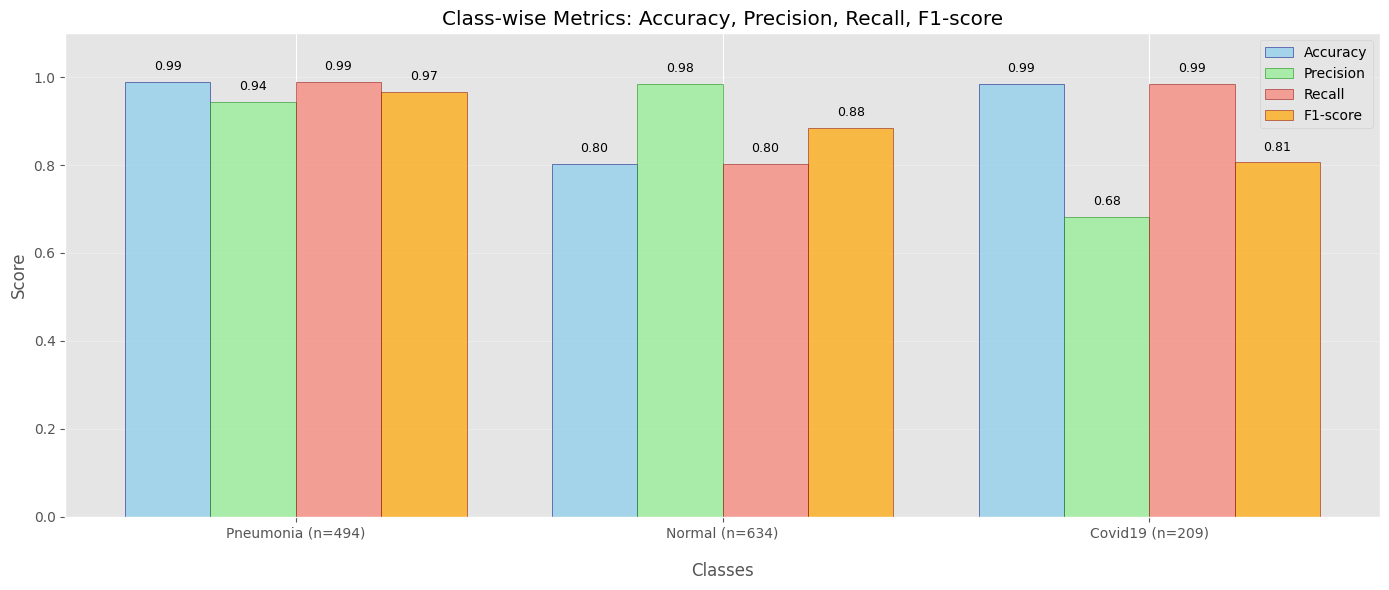

## Grad-CAM

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo grad_model lấy output conv cuối + output dự đoán
grad_model = Model([model.inputs], [model.get_layer("last_conv").output, model.output])

def grad_cam(input_image, true_label=None):
    """
    input_image: shape (1,H,W,C)
    true_label: nếu muốn dùng nhãn thật
    """
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(input_image)
        class_idx = tf.argmax(preds[0])
        if true_label is not None:
            class_idx = tf.constant(true_label)
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))  # global average pooling
    conv_out = conv_out[0]  # bỏ batch
    heatmap = tf.reduce_sum(tf.multiply(conv_out, pooled_grads), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = tf.image.resize(heatmap[...,None], (224,224)).numpy()[...,0]
    return heatmap, int(class_idx)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_870']]
Received: inputs=Tensor(shape=(1, 224, 224, 1))
  warnings.warn(msg)


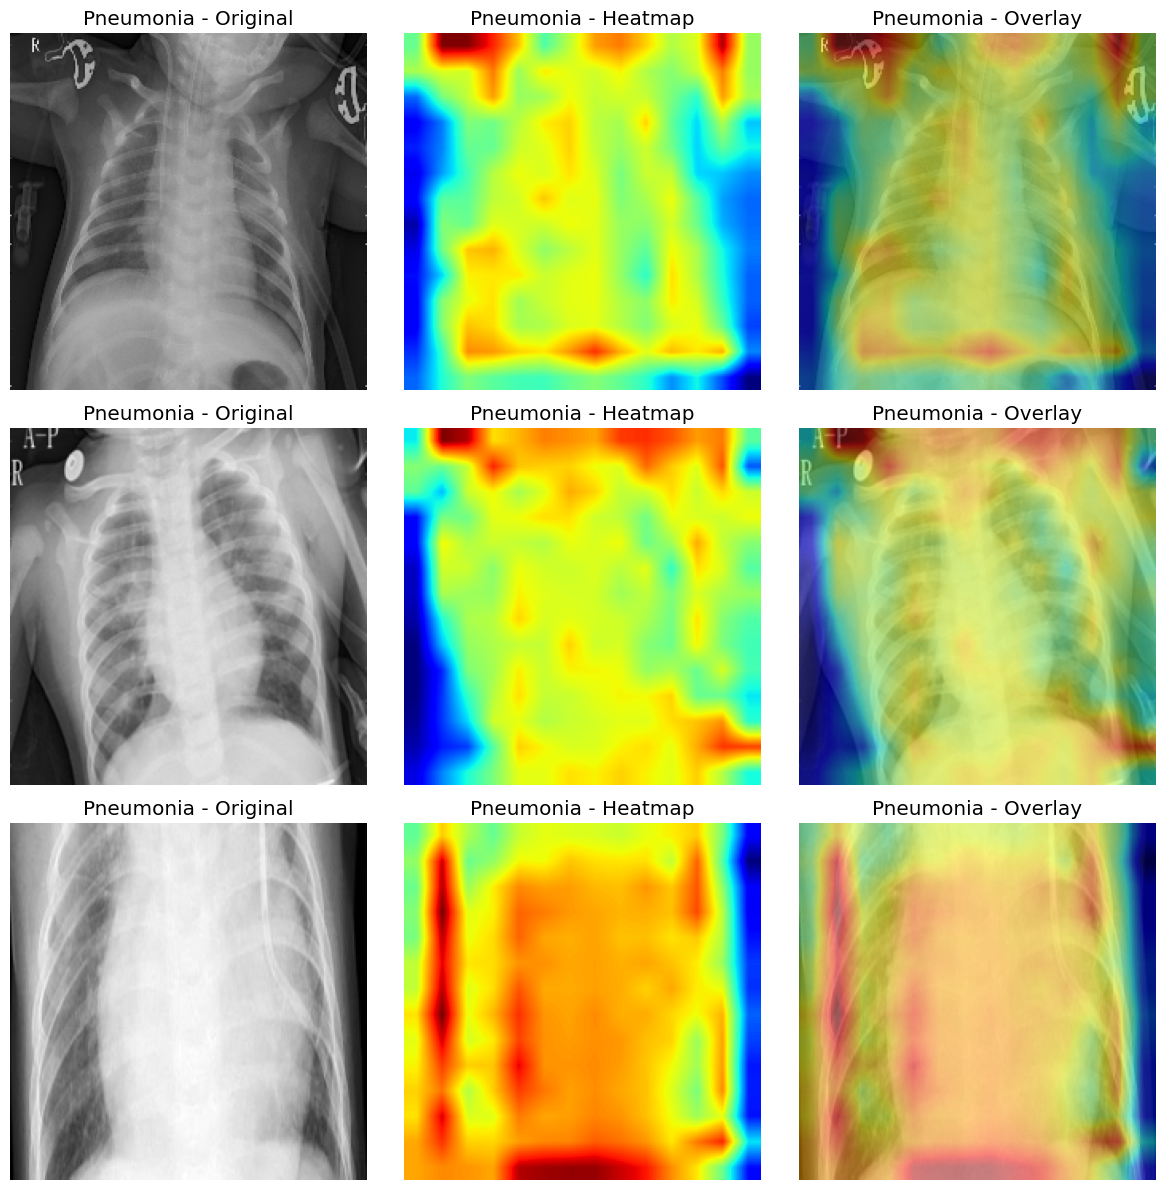

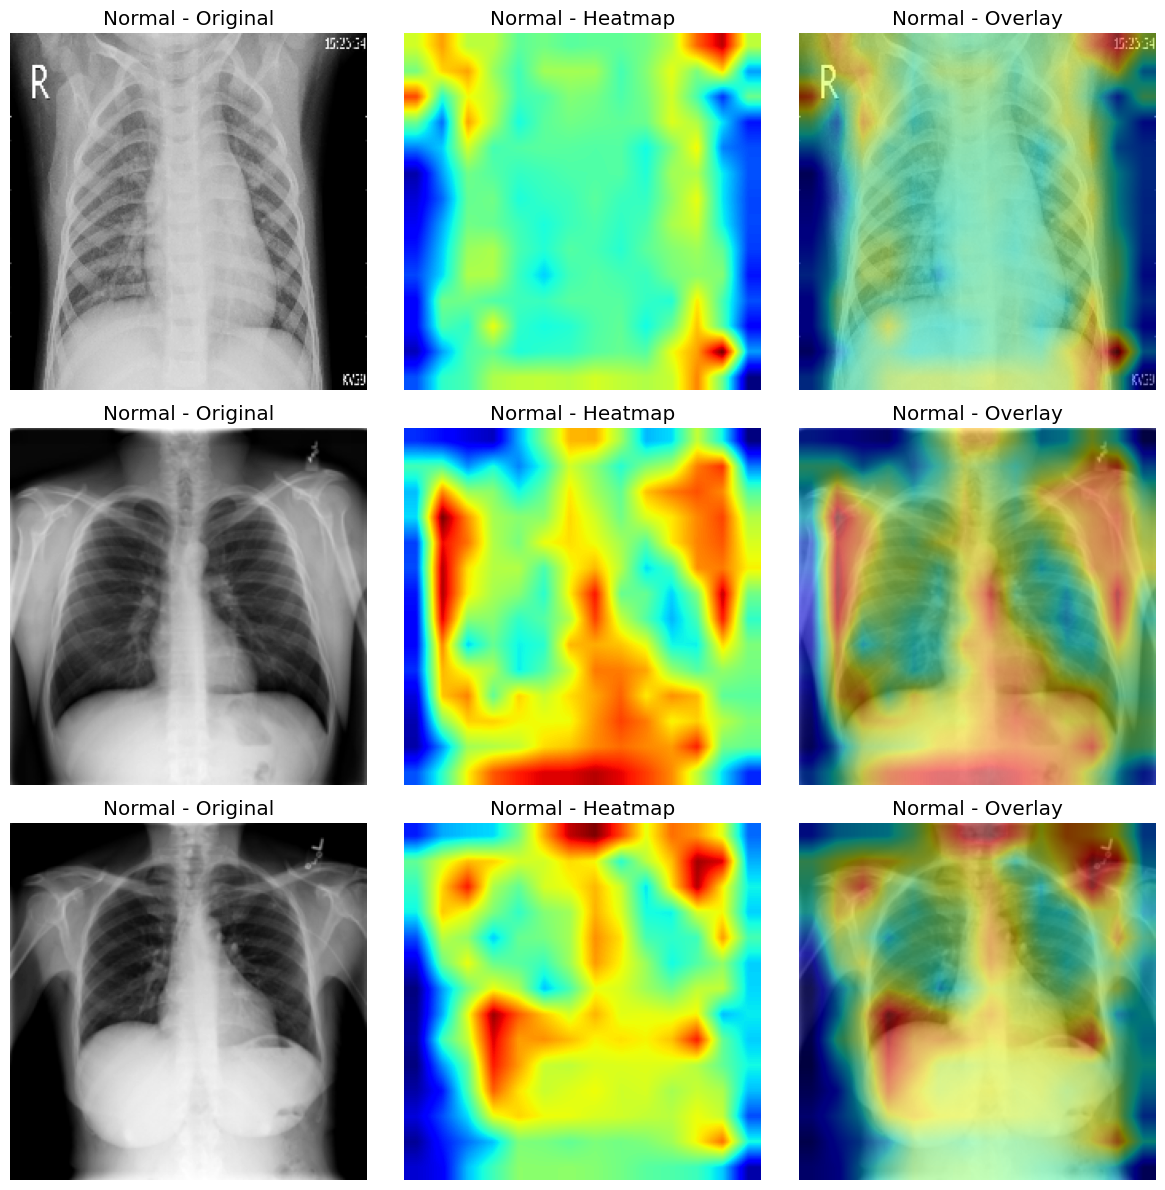

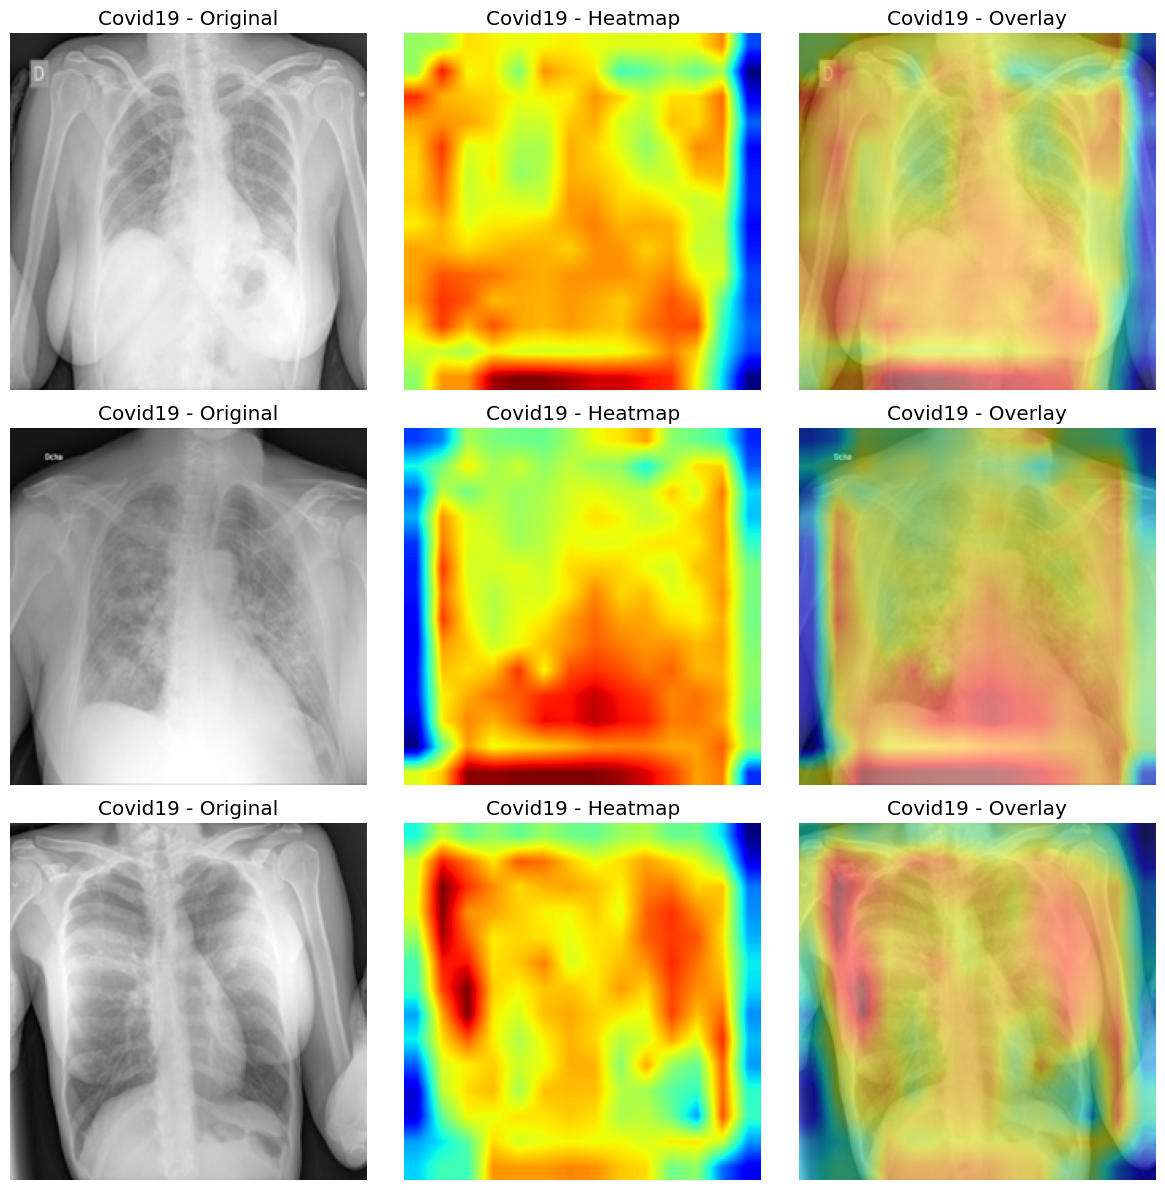

In [107]:
import matplotlib.pyplot as plt
import numpy as np

num_classes = 3
num_per_class = 3
class_names = ['Pneumonia', 'Normal', 'Covid19']

# Duyệt từng class
for cls in range(num_classes):
    # Lấy index của các ảnh thuộc class cls
    idxs = np.where(y_val == cls)[0][:num_per_class]  # 3 ảnh đầu tiên
    
    plt.figure(figsize=(12, 4*num_per_class))
    
    for i, k in enumerate(idxs):
        img = x_val[k][np.newaxis, ...]  # batch dimension
        hm, cls_idx = grad_cam(img)
        
        # Ảnh gốc
        plt.subplot(num_per_class, 3, i*3 + 1)
        plt.imshow(x_val[k].squeeze(), cmap='gray')
        plt.axis('off')
        plt.title(f"{class_names[cls]} - Original")
        
        # Heatmap
        plt.subplot(num_per_class, 3, i*3 + 2)
        plt.imshow(hm, cmap='jet')
        plt.axis('off')
        plt.title(f"{class_names[cls]} - Heatmap")
        
        # Overlay
        plt.subplot(num_per_class, 3, i*3 + 3)
        plt.imshow(x_val[k].squeeze(), cmap='gray')
        plt.imshow(hm, cmap='jet', alpha=0.5)
        plt.axis('off')
        plt.title(f"{class_names[cls]} - Overlay")
    
    plt.tight_layout()
    plt.show()
